@startuml
class ContratoArtista {
  - artista: str
  - reproducciones: int
  - saldo_regalias: float
  + registrar_reproducciones(cantidad): bool
  + cobrar_regalias(monto): bool
  + obtener_saldo_regalias(): float
  + obtener_artista(): str
  + obtener_reproducciones(): int
}
@enduml

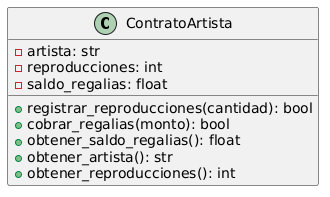

In [23]:
class ContratoArtista:
    def __init__(self, artista: str, tarifa_por_stream: float = 0.004) -> None:
        self.__artista: str = artista
        self.__saldo_regalias: float = 0.0
        self.__reproducciones: int = 0
        self._tarifa_por_stream: float = tarifa_por_stream

    def registrar_reproducciones(self, cantidad: int) -> bool:
        if cantidad > 0:
            self.__reproducciones += cantidad
            ganancia = cantidad * self._tarifa_por_stream
            self.__saldo_regalias += ganancia
            return True
        return False

    def cobrar_regalias(self, monto: float) -> bool:
        if 0 < monto <= self.__saldo_regalias:
            self.__saldo_regalias -= monto
            return True
        return False

    def obtener_saldo_regalias(self) -> float:
        return self.__saldo_regalias

    def obtener_artista(self) -> str:
        return self.__artista

    def obtener_reproducciones(self) -> int:
        return self.__reproducciones

Uso

In [24]:
contrato = ContratoArtista(artista="Luisster", tarifa_por_stream=0.005)

print(f"Artista: {contrato.obtener_artista()}")
print(f"Saldo inicial de regalías: ${contrato.obtener_saldo_regalias()}")

contrato.registrar_reproducciones(100000)
print(f"Saldo tras 100,000 streams: ${contrato.obtener_saldo_regalias()}")

exito = contrato.cobrar_regalias(600)
print(f"¿Cobro exitoso de $600?: {exito}")

contrato.cobrar_regalias(200)
print(f"Saldo final en cuenta: ${contrato.obtener_saldo_regalias()}")

Artista: Luisster
Saldo inicial de regalías: $0.0
Saldo tras 100,000 streams: $500.0
¿Cobro exitoso de $600?: False
Saldo final en cuenta: $300.0


In [25]:
# Intentando acceder a los atributos privados
try:
    print(contrato.__saldo_regalias)
except AttributeError as e:
    print(f"Error: {e}")


Error: 'ContratoArtista' object has no attribute '__saldo_regalias'
